In [1]:
import hashlib
import json
import math
import sys
import os

import requests

from qwen_vl_utils import process_vision_info

# ========== 1. GPU配置（必须在任何CUDA操作之前执行）==========
cuda_num = 6  # 指定使用的GPU编号（0-7）
print(f"Use CUDA: {cuda_num}")
os.environ["CUDA_VISIBLE_DEVICES"] = f"{cuda_num}"  # 设置可见GPU设备
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"  # 允许PyTorch动态扩展显存段
from decord import VideoReader, cpu
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import cv2
from PIL import Image
from peft import PeftModel
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")
def download_video(url, dest_path):
    response = requests.get(url, stream=True)
    with open(dest_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8096):
            f.write(chunk)
    print(f"Video downloaded to {dest_path}")


def get_video_frames(video_path, num_frames=128, cache_dir='.cache'):
    os.makedirs(cache_dir, exist_ok=True)

    video_hash = hashlib.md5(video_path.encode('utf-8')).hexdigest()
    if video_path.startswith('http://') or video_path.startswith('https://'):
        video_file_path = os.path.join(cache_dir, f'{video_hash}.mp4')
        if not os.path.exists(video_file_path):
            download_video(video_path, video_file_path)
    else:
        video_file_path = video_path

    frames_cache_file = os.path.join(cache_dir, f'{video_hash}_{num_frames}_frames.npy')
    timestamps_cache_file = os.path.join(cache_dir, f'{video_hash}_{num_frames}_timestamps.npy')

    if os.path.exists(frames_cache_file) and os.path.exists(timestamps_cache_file):
        frames = np.load(frames_cache_file)
        timestamps = np.load(timestamps_cache_file)
        return video_file_path, frames, timestamps

    vr = VideoReader(video_file_path, ctx=cpu(0))
    total_frames = len(vr)

    indices = np.linspace(0, total_frames - 1, num=num_frames, dtype=int)
    frames = vr.get_batch(indices).asnumpy()
    timestamps = np.array([vr.get_frame_timestamp(idx) for idx in indices])

    np.save(frames_cache_file, frames)
    np.save(timestamps_cache_file, timestamps)
    
    return video_file_path, frames, timestamps

def create_image_grid(images, num_columns=8):
    pil_images = [Image.fromarray(image) for image in images]
    num_rows = math.ceil(len(images) / num_columns)

    img_width, img_height = pil_images[0].size
    grid_width = num_columns * img_width
    grid_height = num_rows * img_height
    grid_image = Image.new('RGB', (grid_width, grid_height))

    for idx, image in enumerate(pil_images):
        row_idx = idx // num_columns
        col_idx = idx % num_columns
        position = (col_idx * img_width, row_idx * img_height)
        grid_image.paste(image, position)

    return grid_image
def apply_lora(model, lora_path):
    """
    加载LoRA（Low-Rank Adaptation）权重到模型
    
    参数说明：
        model: 基础模型（已加载的AutoModel实例）
        lora_path: LoRA权重文件路径
    
    返回值：
        PeftModel: 加载了LoRA权重的模型实例
    """
    model = PeftModel.from_pretrained(model, lora_path)
    return model

Use CUDA: 6


/home/mzhao/.conda/envs/Qwen_back/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

import torch
font_path = 'simhei中易黑体.ttf'
font_prop = fm.FontProperties(fname=font_path)

def setup_chinese_font(font_path='simhei中易黑体.ttf'):
    """设置中文字体"""
    try:
        font_prop = fm.FontProperties(fname=font_path)
        return font_prop
    except:
        print(f"警告: 无法加载字体 {font_path}，使用默认字体")
        return None
def calc_attention_concentration(att_map):
    """
    计算注意力集中度的5个核心指标
    输入: att_map - 形状为 [H, W] 或 [T, H, W] 的注意力图
    返回: dict 包含5个指标
    """
    # 如果是3D (T,H,W)，取时间平均
    if att_map.ndim == 3:
        att_map = np.mean(att_map, axis=0)
    
    # 展平并归一化
    flat = att_map.flatten()
    flat = flat / (flat.sum() + 1e-10)
    
    # 1. 空间熵 (越小越集中)
    non_zero = flat[flat > 0]
    entropy = -np.sum(non_zero * np.log(non_zero))
    
    # 2. 基尼系数 (越接近1越集中)
    sorted_vals = np.sort(flat)
    n = len(sorted_vals)
    cumsum = np.cumsum(sorted_vals)
    gini = (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n
    
    # 3. 有效面积比 (越小越集中)
    sorted_desc = sorted_vals[::-1]
    cumsum_desc = np.cumsum(sorted_desc)
    idx_90 = np.argmax(cumsum_desc >= 0.9)
    area_ratio = (idx_90 + 1) / n
    
    # 4. 峰值均值比 (越大越集中)
    peak_mean = att_map.max() / (att_map.mean() + 1e-10)
    
    # 5. 方差 (越大越集中)
    variance = np.var(att_map)
    
    return {
        'entropy': entropy,
        'gini': gini,
        'area_ratio': area_ratio,
        'peak_mean': peak_mean,
        'variance': variance
    }


# ==================== 注意力热力图可视化 ====================
def overlay_heatmaps_triple(images, heatmaps, check_words, alpha=0.6, save_path=None):
    """
    可视化注意力热力图：纵向排列
    第一行：所有原始图片
    第二行：所有热力图
    第三行：所有叠加图
    
    Args:
        images: 原始图像数组 (N, H, W, C)
        heatmaps: 注意力热力图数组 (N, H_att, W_att)
        check_words: 当前检查的关键词（用于标题）
        alpha: 热力图透明度（0-1之间）
        save_path: 保存路径（可选）
    """
    N = len(images)  # 图像数量
    
    # 创建子图：3行（原图、热力图、叠加图），N列（每个样本一列）
    fig, axes = plt.subplots(3, N, figsize=(2 * N, 2 * 3))
    
    # 如果只有一张图，确保axes是二维数组
    if N == 1:
        axes = axes.reshape(3, -1)
    
    # 遍历每一帧
    for i in range(N):
        img = images[i].astype(np.uint8)
        heatmap = heatmaps[i]
        
        # ---------- 1. 将热力图缩放到图像尺寸 ----------
        heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        
        # ---------- 2. 归一化热力图到0-255 ----------
        heatmap_min, heatmap_max = heatmap_resized.min(), heatmap_resized.max()
        if heatmap_max - heatmap_min > 1e-8:
            heatmap_norm = (heatmap_resized - heatmap_min) / (heatmap_max - heatmap_min)
        else:
            heatmap_norm = heatmap_resized - heatmap_min
        heatmap_norm = (heatmap_norm * 255).astype(np.uint8)
        
        # ---------- 3. 应用颜色映射（JET色图） ----------
        heatmap_color = cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        
        # ---------- 4. 叠加热力图到原图 ----------
        overlay = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
        
        # ---------- 5. 绘制三行图像 ----------
        # 第一行：原始图片
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Frame {i+1}', fontsize=10)
        axes[0, i].axis('off')
        
        # 第二行：热力图
        axes[1, i].imshow(heatmap_color)
        axes[1, i].set_title(f'Heatmap {i+1}', fontsize=10)
        axes[1, i].axis('off')
        
        # 第三行：叠加图
        axes[2, i].imshow(overlay)
        axes[2, i].set_title(f'Overlay {i+1}', fontsize=10)
        axes[2, i].axis('off')
    
    # 添加行标签（在左侧）
    row_labels = ['Original', 'Heatmap', 'Overlay']
    for row in range(3):
        axes[row, 0].set_ylabel(row_labels[row], fontsize=12, fontweight='bold', 
                                rotation=90, labelpad=10)
    
    # 添加总标题
    plt.suptitle(f'Attention Visualization for "{check_words}"', fontsize=14, 
                 fontproperties=font_prop, y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"图片已保存到: {save_path}")
    
    # plt.show()
    # return plt

# ==================== 视频帧提取函数 ====================
def extract_frames(video_path, num_frames=None):
    """
    从视频中等间隔提取指定数量的帧
    
    Args:
        video_path: 视频文件路径
        num_frames: 需要提取的帧数
    
    Returns:
        tuple: (采样帧数组, 帧索引列表)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"无法打开视频: {video_path}")
    
    # ---------- 1. 获取视频信息 ----------
    fps_original = cap.get(cv2.CAP_PROP_FPS)          # 原始帧率
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 总帧数
    duration = total_frames / fps_original            # 视频时长（秒）
    
    # print(f"视频: {total_frames}帧, {fps_original:.2f}fps, 时长: {duration:.3f}秒")
    if num_frames is None:
        num_frames=total_frames
    # print(f"目标提取帧数: {num_frames}")
    
    # ---------- 2. 计算采样帧索引 ----------
    if num_frames > 1:
        frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    else:
        frame_indices = [total_frames // 2]  # 只取中间帧
    
    # print(f"采样帧索引: {frame_indices}")
    
    # ---------- 3. 提取指定帧 ----------
    sampled_frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)  # 跳转到指定帧
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # BGR转RGB
            sampled_frames.append(frame)
    
    cap.release()
    # print(f"成功提取: {len(sampled_frames)}帧")
    
    return np.array(sampled_frames), frame_indices
def extract_attentions(gpt_msg,result,processor,save_path=None,vis=True):
    output_atts = result["outputs_dict"]["attentions"]  # 注意力权重
    response = result["response_msg"]                   # 模型预测结果
    # print(response)
    generated_ids = result["outputs_dict"].sequences    # 完整生成序列
    input_ids = result["inputs_dict"].input_ids         # 输入token序列

    # ---------- 6. 获取视觉特征的时空维度 ----------
    if hasattr(result["inputs_dict"], "image_grid_thw"):
        t, h, w = result["inputs_dict"]["image_grid_thw"][0]  # 图像：时间、高、宽
    
    if hasattr(result["inputs_dict"], "video_grid_thw"):
        t, h, w = result["inputs_dict"]["video_grid_thw"][0]  # 视频：时间、高、宽
    
    if vis: print("batch, h, w:", (t, h, w))

    # ---------- 7. 查找视觉token范围 ----------
    # 构建完整的输入token序列（包含输入部分）
    generated_ids_all = [
        out_ids[:len(in_ids)] 
        for in_ids, out_ids in zip(input_ids, generated_ids)
    ]
    
    vision_start = -1
    vision_end = -1
    
    # 遍历token，找到视觉开始和结束标记
    for idx, token in enumerate(generated_ids_all[0]):
        word = processor.tokenizer.decode([token])
        if word == "<|image_pad|>" or word == "<|video_pad|>":
            continue
        if vis: print(idx, word, end=" ")
        if word == "<|vision_start|>":
            vision_start = idx
        if word == "<|vision_end|>":
            vision_end = idx
    
    # 提取输出部分的token
    generated_ids_output = [
        out_ids[len(in_ids):] 
        for in_ids, out_ids in zip(input_ids, generated_ids)
    ]
    
    print("\n" + "="*50)
    print("输出token序列:")
    for idx, token in enumerate(generated_ids_output[0]):
        word = processor.tokenizer.decode([token])
        print(idx, word, end=" ")

    print("\n")
    # 注意力范围：视觉开始之后到视觉结束
    att_range_start = vision_start + 1
    att_range_end = vision_end
    print("注意力提取区间:",att_range_start,att_range_end)

    # ---------- 8. 提取特定词的注意力 ----------
    # word_num_start, word_num_end = 18, 23  # 取第一个输出token
    word_num_start, word_num_end = map(int, input("请输入起始和结束索引（空格分割）: ").split())
    print("输入的词索引:",word_num_start, word_num_end)
    check_words = processor.decode(generated_ids_output[0][word_num_start:word_num_end], skip_special_tokens=False)
    print("\n\n检查关键词:", check_words)

    # 提取对应token的注意力权重
    atts = output_atts[word_num_start:word_num_end]  # (num_words, num_layers, batch, heads, seq_len, ...)

    # 整理注意力数据结构
    all_words_attention = []
    for word_att in atts:
        all_lays_attention = []
        for lay_att in word_att:
            heads_attention = []
            for head_idx in range(28):  # 28个注意力头
                att_list = lay_att[0, head_idx, 0, att_range_start:att_range_end]  # 只取视觉部分
                att_map = att_list
                heads_attention.append(att_map.cpu().float())
            all_lays_attention.append(heads_attention)
        all_words_attention.append(all_lays_attention)
    
    # 转换为numpy数组: (words, layers, heads, visual_tokens, h, w)
    all_words_attention = np.array(all_words_attention)
    if vis: print("all_words_attention shape:", all_words_attention.shape)

    # ---------- 9. 聚合注意力权重 ----------
    # 跨词平均 -> (layers, heads, visual_tokens, h, w)
    word_att = np.mean(all_words_attention, axis=0)
    # 跨层平均 -> (heads, visual_tokens, h, w)
    layer_att = np.mean(word_att, axis=0)
    # 跨头平均 -> (visual_tokens, h, w)
    head_att = np.mean(layer_att, axis=0)
    
    if vis: print("word_att shape:", word_att.shape)
    if vis: print("layer_att shape:", layer_att.shape)
    if vis: print("head_att shape:", head_att.shape)
    if vis: print("视觉token数量:", len(generated_ids_all[0][att_range_start:att_range_end]))

    # ---------- 10. 重塑注意力图并可视化 ----------
    # 将注意力图重塑为 (t, h//2, w//2)
    reshape_att = head_att.reshape([t, h//2, w//2])
    print("重塑后注意力图 shape:", reshape_att.shape)
    result2 = calc_attention_concentration(reshape_att)

    # 打印结果
    print(f"空间熵: {result2['entropy']:.4f}")
    print(f"基尼系数: {result2['gini']:.4f}")
    print(f"有效面积比: {result2['area_ratio']*100:.2f}%")
    print(f"峰值均值比: {result2['peak_mean']:.2f}")
    print(f"方差: {result2['variance']:.6f}")


    # 处理图像数据
    if hasattr(result["inputs_dict"], "image_grid_thw"):
        file_path =gpt_msg["image"][0]
        img = Image.open(file_path)
        img_np = np.array([img])  # 单张图像
        frames = img_np
        if vis: print("frames.shape:", frames.shape)
        if vis: print("head_att.shape:", reshape_att.shape)
        
        # 可视化并保存
        return overlay_heatmaps_triple(
            frames, reshape_att, check_words, alpha=0.5, 
            save_path=save_path
        )
    
    # 处理视频数据
    if hasattr(result["inputs_dict"], "video_grid_thw"):
        
        video_path =gpt_msg["video"][0]
        print("正在处理视频数据...",video_path)
        frames, frame_indices = extract_frames(video_path, num_frames=t)
        if vis: print("frames.shape:", frames.shape)
        if vis: print("reshape_att.shape:", reshape_att.shape)
        
        # 可视化并保存
        return overlay_heatmaps_triple(
            frames, reshape_att, check_words, alpha=0.5, 
            save_path=save_path
        )
def inference(model,processor,video, prompt):
    """
    执行模型推理
    
    Args:
        video: 视频路径
        prompt: 输入提示
        max_new_tokens: 最大生成token数
        total_pixels: 总像素数
        min_pixels: 最小像素数
        max_frames: 最大帧数
        sample_fps: 采样帧率
    
    Returns:
        Dict: 包含推理结果、输入输出、响应和参考数据的字典
    """
    
    model.eval()  # 切换到评估模式
    
    # ---------- 1. 构建输入数据 ----------
    messages = [
            {"role": "user", "content": [
                    {"video": video,
                    "fps": 4, 
                    "min_pixels": 224 * 224,
                    "max_pixels": 224 * 224,
                    "min_frames": 16,
                    "max_frames": 64 },              # 最多8帧
                    {"type": "text", "text": prompt},
                ]
            }
        ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs, video_kwargs = process_vision_info(messages, return_video_kwargs=True)
    
    # 处理输入：文本、图像、视频
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
        **video_kwargs
    )
    
    # 将输入移到GPU
    device = next(model.parameters()).device
    inputs = inputs.to("cuda:0")

    # ---------- 2. 配置生成参数 ----------
    generation_kwargs = {
        "do_sample": False,              # 贪婪解码（确定性输出）
        "num_beams": 1,                  # 束搜索宽度（1表示贪婪搜索）
        "max_new_tokens": 200,           # 最大生成token数（原500过长）
        "min_new_tokens": 1,             # 最少生成token数
        "repetition_penalty": 1.2,       # 重复惩罚系数（防止生成循环）
        "eos_token_id": processor.tokenizer.eos_token_id,  # 结束符token ID
        "pad_token_id": processor.tokenizer.pad_token_id,  # 填充符token ID
    }
    # generation_kwargs = {
    #     "do_sample": False,
    #     "num_beams": 1,
    #     "max_new_tokens": 500,
    # }
    # ---------- 3. 执行模型推理 ----------
    with torch.no_grad():  # 禁用梯度计算以节省内存
        outputs = model.generate(
            **inputs,
            **generation_kwargs,
            return_dict_in_generate=True,  # 返回字典格式
            output_scores=True,             # 输出分数
            output_hidden_states=False,     # 不输出隐藏状态
            output_attentions=True  # 根据需要输出注意力权重
        )
        



    generated_ids = outputs.sequences  # 生成的token序列

    # ---------- 4. 解码生成的token ----------
    # 去除输入部分，只保留新生成的token
    generated_ids_trimmed = [
        out_ids[len(in_ids):] 
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    # 将token序列解码为文本
    response = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]
    

    # ---------- 5. 返回结果 ----------
    return {
        "success": True,
        "inputs_dict": inputs,          # 输入数据字典
        "outputs_dict": outputs,        # 输出数据字典
        "input_msg": messages,          # 原始输入消息
        "response_msg": response,       # 模型预测结果
    }


In [ ]:
from transformers import AutoProcessor, AutoModelForVision2Seq
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers")
import os 


model_path = "Qwen2.5-VL-7B-Instruct" #  The following output example is from a tiny test model

processor = AutoProcessor.from_pretrained(model_path)


model, output_loading_info = AutoModelForVision2Seq.from_pretrained(model_path, torch_dtype="auto", device_map="auto", output_loading_info=True,attn_implementation="eager")


print("output_loading_info", output_loading_info)

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 5/5 [01:39<00:00, 19.90s/it]

output_loading_info {'missing_keys': [], 'unexpected_keys': [], 'mismatched_keys': [], 'error_msgs': []}


qwen-vl-utils using decord to read video.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


64
视频路径: ../../Data/dicom_videos_group/Dataset/group_1/2024031509524300050569525e9/Doppler_Parasternal_Long.mp4
在提供的图片中可以看到彩色多普勒显示了心脏内部血流的情况，在红色和蓝色分别代表血液流动的方向不同（红色表示向心方向，即从主动脉流向左房；而蓝色则相反）。如果存在二尖瓣反流，则会看到部分或全部颜色反转的现象。

然而仅凭一张静态图像无法准确判断是否存在二尖瓣反流以及其严重程度。通常需要结合多个切面、动态变化等信息进行综合分析才能做出诊断结论。
建议您咨询专业医生以获得更详细的解释与指导。

输出token序列:
0 在 1 提供的 2 图片 3 中 4 可以看到 5 彩色 6 多 7 普 8 勒 9 显示 10 了 11 心脏 12 内部 13 血 14 流 15 的情况 16 ，在 17 红色 18 和 19 蓝色 20 分别 21 代表 22 血液 23 流动 24 的方向 25 不同 26 （ 27 红色 28 表示 29 向 30 心 31 方向 32 ， 33 即 34 从 35 主动 36 脉 37 流向 38 左 39 房 40 ； 41 而 42 蓝色 43 则 44 相反 45 ）。 46 如果 47 存在 48 二 49 尖 50 瓣 51 反 52 流 53 ，则 54 会 55 看到 56 部分 57 或 58 全部 59 颜色 60 反转 61 的现象 62 。

 63 然而 64 仅 65 凭 66 一张 67 静态 68 图像 69 无法 70 准确 71 判断 72 是否存在 73 二 74 尖 75 瓣 76 反 77 流 78 以及 79 其 80 严重 81 程度 82 。 83 通常 84 需要 85 结合 86 多个 87 切 88 面 89 、 90 动态 91 变化 92 等 93 信息 94 进行 95 综合 96 分析 97 才能 98 做出 99 诊断 100 结论 101 。
 102 建议 103 您 104 咨询 105 专业 106 医生 107 以 108 获得 109 更 110 详细的 111 解释 112 与 113 指导 114 。 115 <|im_end|> 

注意力提取

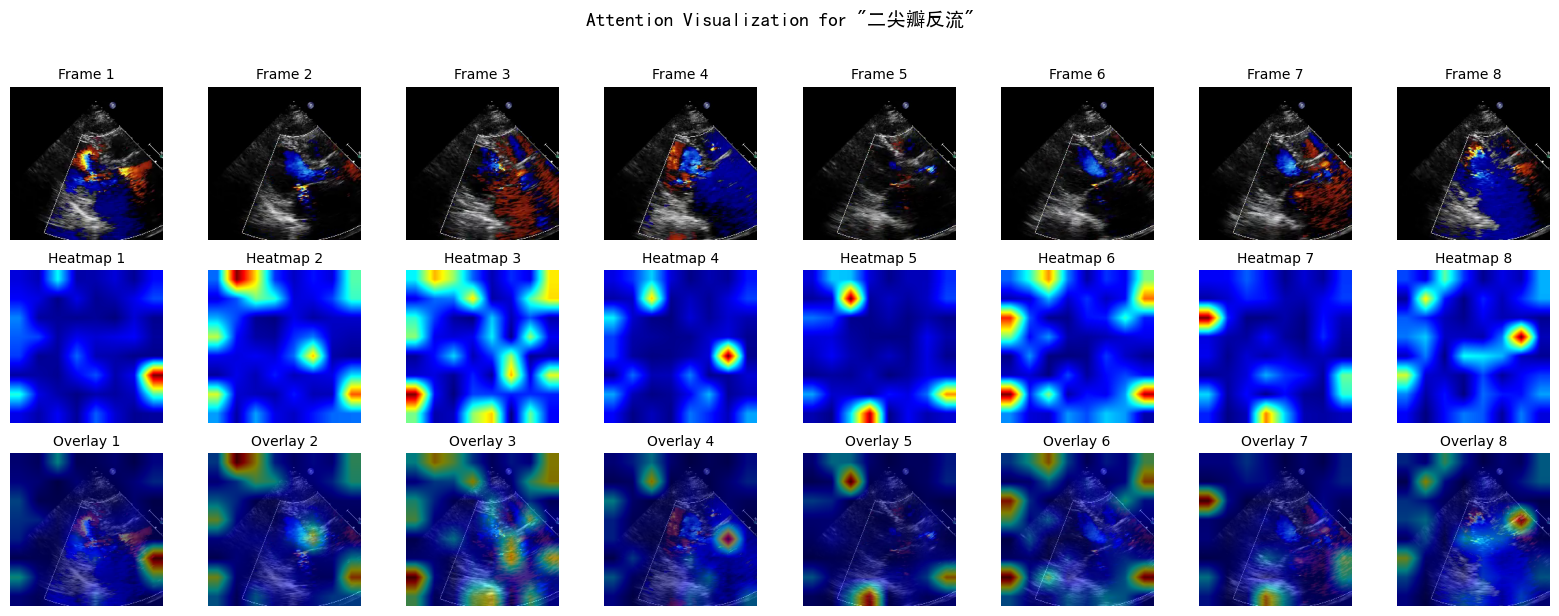

In [4]:
###  2.   有视频
msg=   {
    "id": "Dataset/group_1/2024031509524300050569525e9",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_1/2024031509524300050569525e9/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_1/2024042221485800050569525e9/Doppler_Parasternal_Long.mp4
在提供的图片中可以看到心脏内部结构的一部分，在包括了心室和可能的心房区域。然而，由于图像仅显示了一部分视图且没有提供完整的动态序列或连续帧来分析整个心动周期中的血流动态情况（例如：舒张期与收缩期），因此无法准确判断是否存在二尖瓣反流及其严重程度。

通常情况下，通过二维彩色多普勒成像可以评估二尖瓣功能状态以及检测到任何异常血液动力学现象如反流的存在与否及程度如何。
建议您咨询专业心血管医生以获得更详细的信息并进行必要的检查诊断。

输出token序列:
0 在 1 提供的 2 图片 3 中 4 可以看到 5 心脏 6 内部 7 结构 8 的一部分 9 ，在 10 包括 11 了 12 心 13 室 14 和 15 可能 16 的心 17 房 18 区域 19 。 20 然而 21 ， 22 由于 23 图像 24 仅 25 显示 26 了一 27 部分 28 视 29 图 30 且 31 没有 32 提供 33 完整的 34 动态 35 序列 36 或 37 连续 38 帧 39 来 40 分析 41 整个 42 心动 43 周期 44 中的 45 血 46 流动 47 态 48 情况 49 （ 50 例如 51 ： 52 舒 53 张 54 期 55 与 56 收缩 57 期 58 ）， 59 因此 60 无法 61 准确 62 判断 63 是否存在 64 二 65 尖 66 瓣 67 反 68 流 69 及其 70 严重 71 程度 72 。

 73 通常 74 情况下 75 ， 76 通过 77 二维 78 彩色 79 多 80 普 81 勒 82 成 83 像 84 可以 85 评估 86 二 87 尖 88 瓣 89 功能 90 状态 91 以及 92 检测 93 到 94 任何 95 异常 96 血液 97 动力 98 学 99 现象 100 如 101 反 102 流 103 的存在 104 与否 105 及 106 程度 107 如何 108 。
 109 建议 110 您 111 咨询 112 专业 113 心血管 114 医

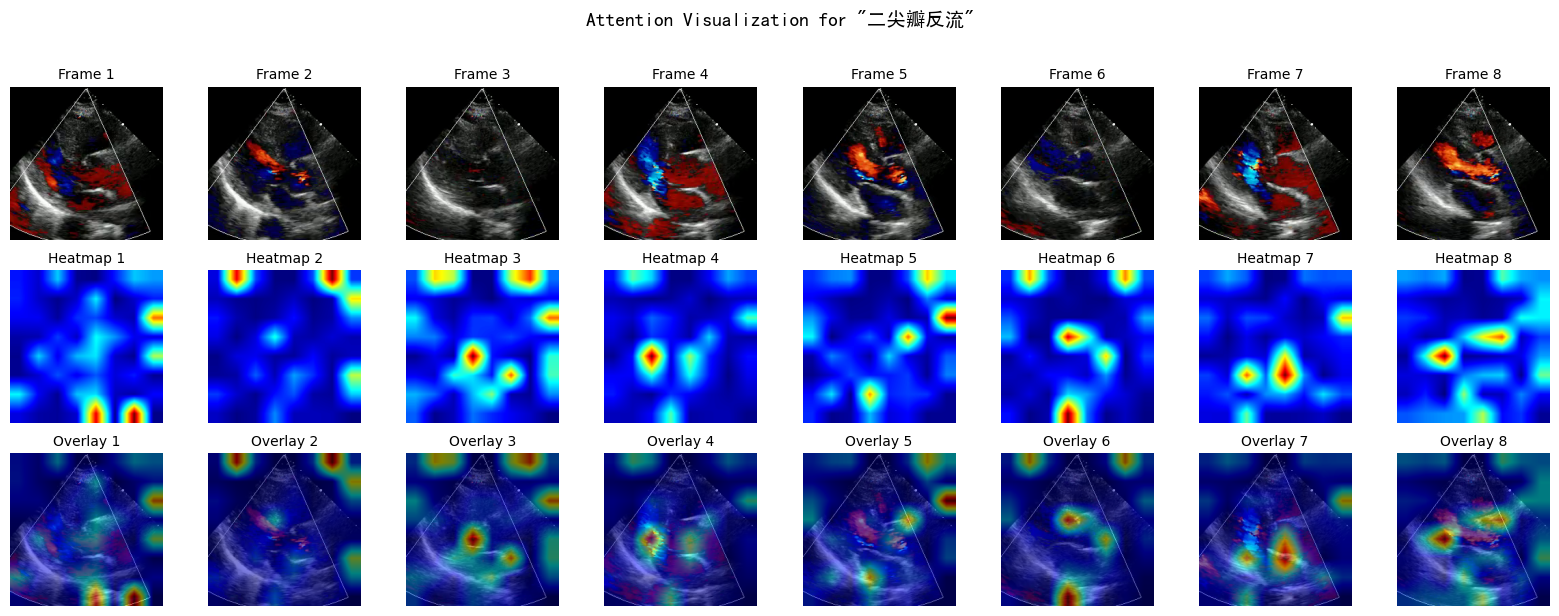

In [5]:
###  2.   有视频
msg=  {
    "id": "Dataset/group_1/2024042221485800050569525e9",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_1/2024042221485800050569525e9/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": -1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "否"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_1/2024052312563900050569557e8/Doppler_Parasternal_Long.mp4
在提供的图片中可以看到二尖瓣存在明显的反流现象（蓝色和红色混合的颜色），这表明有一定程度的二尖瓣反流。然而，在仅凭一张静态图像无法准确评估二尖瓣反流的程度。通常需要结合多个切面、心动周期的不同阶段以及彩色多普勒血流成像来全面评价二尖瓣反流的情况。

如果要我根据这张图进行初步判断的话：从这个角度上看，似乎显示了严重的二尖瓣反流迹象——颜色覆盖范围广且强度高；但请注意这只是基于单帧影像的一个粗略估计，请务必咨询专业医生以获得确切诊断与治疗建议。


输出token序列:
0 在 1 提供的 2 图片 3 中 4 可以看到 5 二 6 尖 7 瓣 8 存在 9 明显的 10 反 11 流 12 现象 13 （ 14 蓝色 15 和 16 红色 17 混合 18 的颜色 19 ）， 20 这 21 表明 22 有 23 一定程度 24 的 25 二 26 尖 27 瓣 28 反 29 流 30 。 31 然而 32 ，在 33 仅 34 凭 35 一张 36 静态 37 图像 38 无法 39 准确 40 评估 41 二 42 尖 43 瓣 44 反 45 流 46 的程度 47 。 48 通常 49 需要 50 结合 51 多个 52 切 53 面 54 、 55 心动 56 周期 57 的不同 58 阶段 59 以及 60 彩色 61 多 62 普 63 勒 64 血 65 流 66 成 67 像 68 来 69 全面 70 评价 71 二 72 尖 73 瓣 74 反 75 流 76 的情况 77 。

 78 如果 79 要 80 我 81 根据 82 这张 83 图 84 进行 85 初步 86 判断 87 的话 88 ： 89 从 90 这个 91 角度 92 上看 93 ， 94 似乎 95 显示 96 了 97 严重的 98 二 99 尖 100 瓣 101 反 102 流 103 迹象 104 —— 105 颜色 106 覆盖 107 范围 108 广 109 且 110 强度 111 高 112 ； 113 但 114 请注意 11

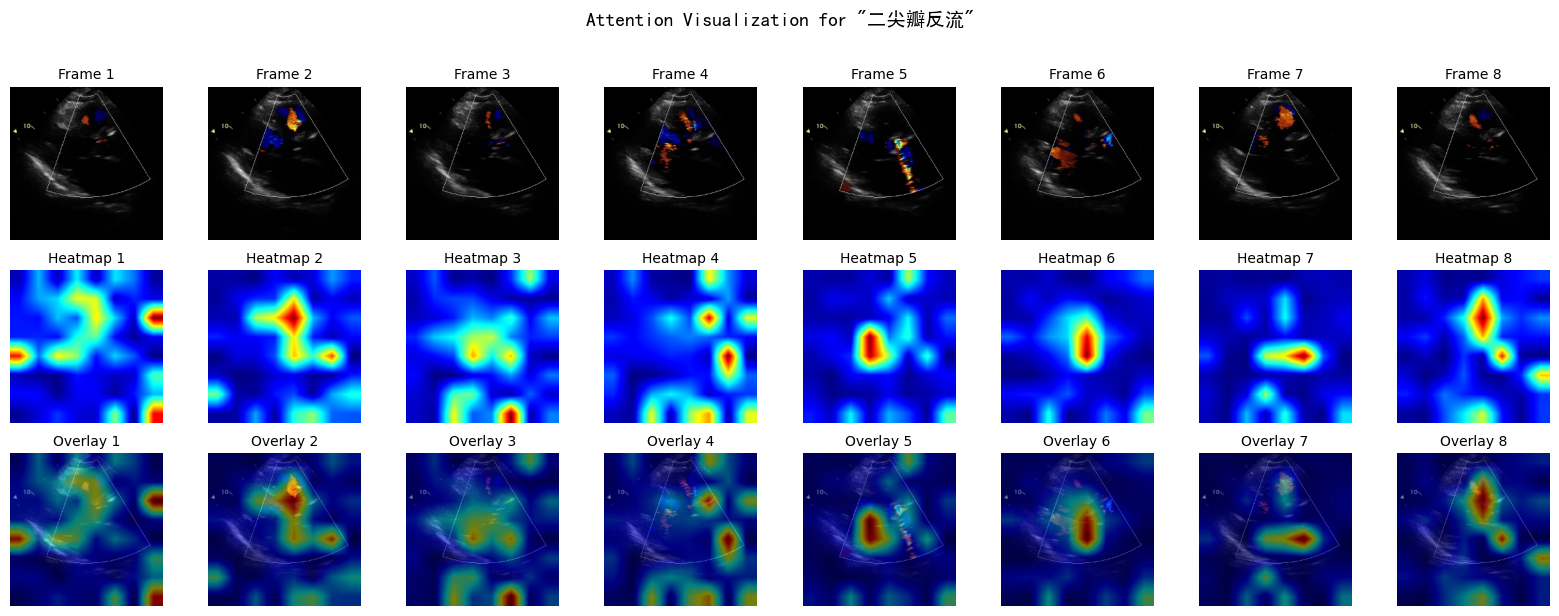

In [6]:
###  2.   有视频
msg= {
    "id": "Dataset/group_1/2024052312563900050569557e8",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_1/2024052312563900050569557e8/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_1/2024052117500200050569557e8/Doppler_Parasternal_Long.mp4
在提供的图片中可以看到彩色多普勒显示了心脏内部血流的情况，在图中的蓝色和黄色区域代表血液向心流动（即正向性），而红色则表示血液离开心脏流向周围组织或血管（即逆向）。根据这个信息我们可以看到图像中心有一个明显的橙色到黄色再到蓝色的颜色过渡带，这通常与二尖瓣关闭不全有关。

然而需要注意的是，仅凭一张静态图片很难准确判断是否存在二尖瓣反流以及它的具体严重程度。对于这种情况需要结合整个心动周期内的动态变化来做出诊断。
建议您咨询专业的医疗人员以获得更详细的评估结果及治疗方案推荐。

输出token序列:
0 在 1 提供的 2 图片 3 中 4 可以看到 5 彩色 6 多 7 普 8 勒 9 显示 10 了 11 心脏 12 内部 13 血 14 流 15 的情况 16 ，在 17 图 18 中的 19 蓝色 20 和 21 黄色 22 区域 23 代表 24 血液 25 向 26 心 27 流动 28 （ 29 即 30 正 31 向 32 性 33 ）， 34 而 35 红色 36 则 37 表示 38 血液 39 离 40 开心 41 脏 42 流向 43 周围 44 组织 45 或 46 血管 47 （ 48 即 49 逆 50 向 51 ）。 52 根据 53 这个 54 信息 55 我们可以 56 看到 57 图像 58 中心 59 有一个 60 明显的 61 橙 62 色 63 到 64 黄色 65 再到 66 蓝色 67 的颜色 68 过渡 69 带 70 ， 71 这 72 通常 73 与 74 二 75 尖 76 瓣 77 关闭 78 不 79 全 80 有关 81 。

 82 然而 83 需要注意 84 的是 85 ， 86 仅 87 凭 88 一张 89 静态 90 图片 91 很难 92 准确 93 判断 94 是否存在 95 二 96 尖 97 瓣 98 反 99 流 100 以及 101 它的 102 具体 103 严重 104 程度 105 。 106 对于 107 这种情况 108 需要 109 结合 110 整个 

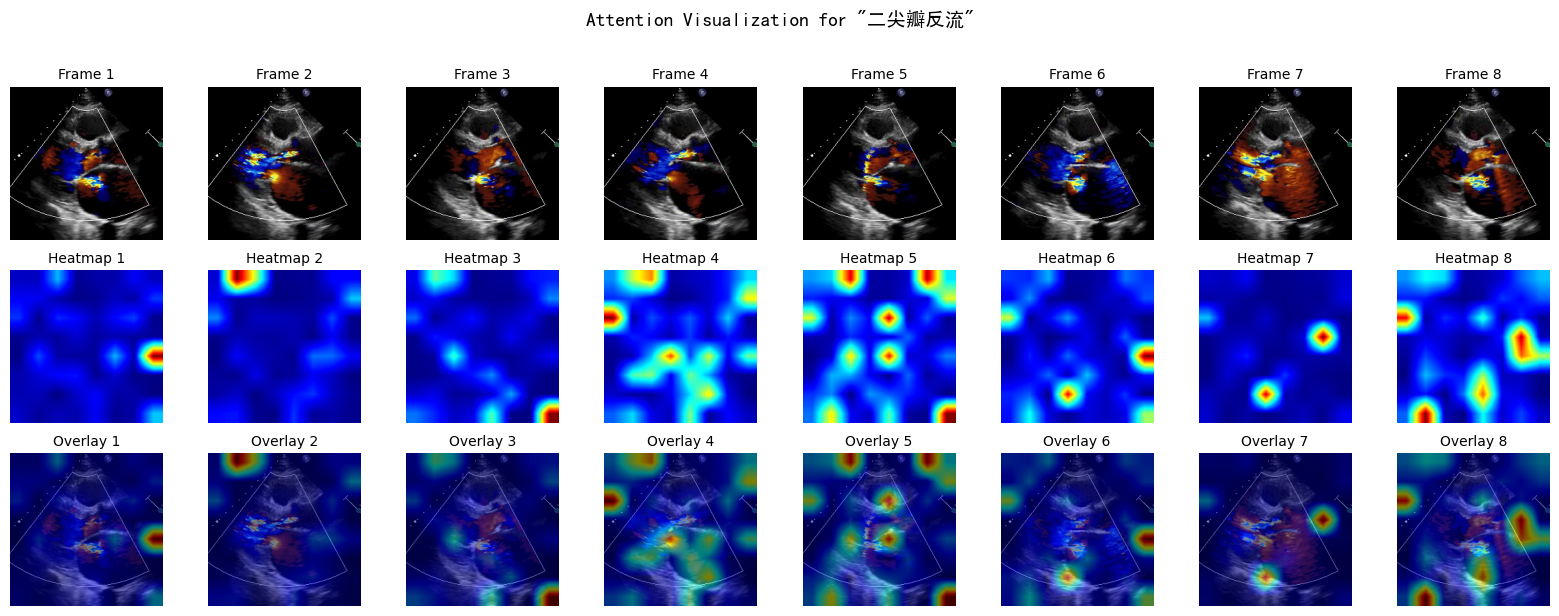

In [7]:
###  2.   有视频
msg=  {
    "id": "Dataset/group_1/2024052117500200050569557e8",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_1/2024052117500200050569557e8/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_5/2024032814245900050569525e9/Doppler_Parasternal_Long.mp4
在提供的图片中可以看到彩色多普勒显示了心脏内部血流的情况，在蓝色和红色分别代表血液向心方向流动（即收缩期）以及离开心脏的方向（舒张期）。从图上看，二尖瓣区域有明显的蓝色信号出现，这通常提示着可能存在二尖瓣反流的现象。

然而仅凭一张静态图像很难准确判断出具体的反流量程或类型(例如是否为功能性还是解剖性)等信息,需要结合临床症状、病史以及其他检查结果综合分析才能做出诊断结论。
建议您咨询专业的医生以获得更详细的解释与指导。

输出token序列:
0 在 1 提供的 2 图片 3 中 4 可以看到 5 彩色 6 多 7 普 8 勒 9 显示 10 了 11 心脏 12 内部 13 血 14 流 15 的情况 16 ，在 17 蓝色 18 和 19 红色 20 分别 21 代表 22 血液 23 向 24 心 25 方向 26 流动 27 （ 28 即 29 收缩 30 期 31 ） 32 以及 33 离 34 开心 35 脏 36 的方向 37 （ 38 舒 39 张 40 期 41 ）。 42 从 43 图 44 上看 45 ， 46 二 47 尖 48 瓣 49 区域 50 有 51 明显的 52 蓝色 53 信号 54 出现 55 ， 56 这 57 通常 58 提示 59 着 60 可能存在 61 二 62 尖 63 瓣 64 反 65 流 66 的现象 67 。

 68 然而 69 仅 70 凭 71 一张 72 静态 73 图像 74 很难 75 准确 76 判断 77 出 78 具体的 79 反 80 流量 81 程 82 或 83 类型 84 ( 85 例如 86 是否 87 为 88 功能性 89 还是 90 解 91 剖 92 性 93 ) 94 等 95 信息 96 , 97 需要 98 结合 99 临床 100 症状 101 、 102 病 103 史 104 以及其他 105 检查 106 结果 107 综合 108 分析 109 才能 110 做出 111 诊断 112 结论 113 。
 114 建议 115 您 1

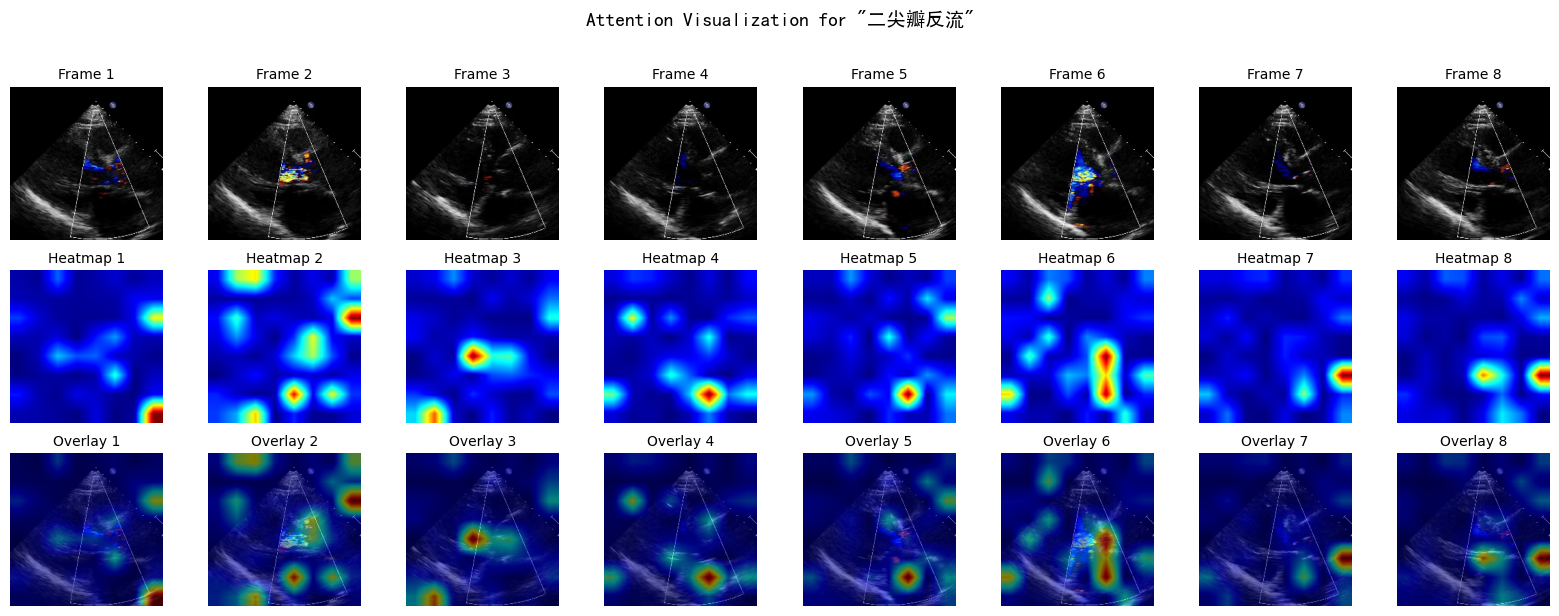

In [9]:
###  2.   有视频
msg= {
    "id": "Dataset/group_5/2024032814245900050569525e9",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_5/2024032814245900050569525e9/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_5/2024032814245900050569525e9/Doppler_Parasternal_Long.mp4
在提供的图片中可以看到彩色多普勒显示了心脏内部血流的情况，在蓝色和红色分别代表血液向心方向流动（即收缩期）以及离开心脏的方向（舒张期）。从图上看，二尖瓣区域有明显的蓝色信号出现，这通常提示着可能存在二尖瓣反流的现象。

然而仅凭一张静态图像很难准确判断出具体的反流量程或类型(例如是否为功能性还是解剖性)等信息,需要结合临床症状、病史以及其他检查结果综合分析才能做出诊断结论。
建议您咨询专业的医生以获得更详细的解释与指导。

输出token序列:
0 在 1 提供的 2 图片 3 中 4 可以看到 5 彩色 6 多 7 普 8 勒 9 显示 10 了 11 心脏 12 内部 13 血 14 流 15 的情况 16 ，在 17 蓝色 18 和 19 红色 20 分别 21 代表 22 血液 23 向 24 心 25 方向 26 流动 27 （ 28 即 29 收缩 30 期 31 ） 32 以及 33 离 34 开心 35 脏 36 的方向 37 （ 38 舒 39 张 40 期 41 ）。 42 从 43 图 44 上看 45 ， 46 二 47 尖 48 瓣 49 区域 50 有 51 明显的 52 蓝色 53 信号 54 出现 55 ， 56 这 57 通常 58 提示 59 着 60 可能存在 61 二 62 尖 63 瓣 64 反 65 流 66 的现象 67 。

 68 然而 69 仅 70 凭 71 一张 72 静态 73 图像 74 很难 75 准确 76 判断 77 出 78 具体的 79 反 80 流量 81 程 82 或 83 类型 84 ( 85 例如 86 是否 87 为 88 功能性 89 还是 90 解 91 剖 92 性 93 ) 94 等 95 信息 96 , 97 需要 98 结合 99 临床 100 症状 101 、 102 病 103 史 104 以及其他 105 检查 106 结果 107 综合 108 分析 109 才能 110 做出 111 诊断 112 结论 113 。
 114 建议 115 您 1

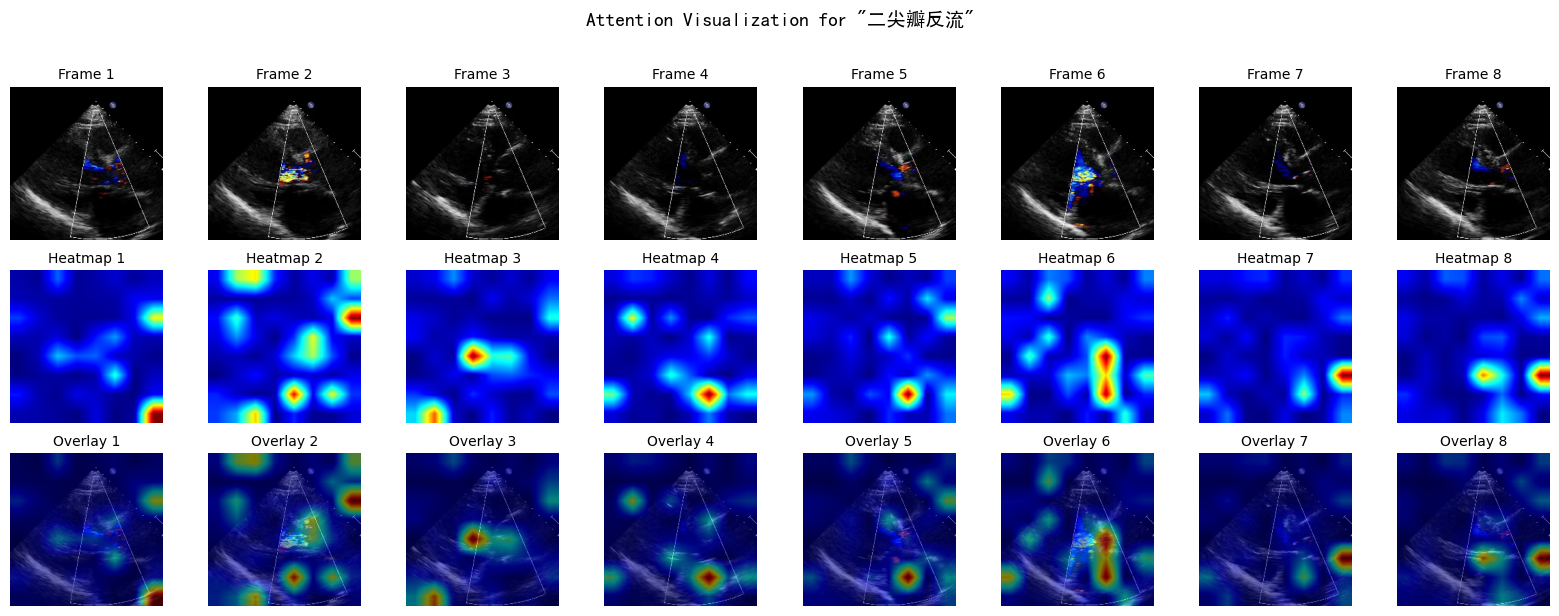

In [10]:
###  2.   有视频
msg= {
    "id": "Dataset/group_5/2024032814245900050569525e9",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_5/2024032814245900050569525e9/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_5/2024041804351700050569525e9/Doppler_Parasternal_Long.mp4
在提供的图片中可以看到心脏内部结构的一部分，在显示了彩色多普勒信号（红色和蓝色）。这些颜色通常代表血液流动的方向：红色表示向心方向的血流，而蓝色则表示离心方向的血流。

从图中的可见的信息来看：
- 二尖瓣位于左房室之间。
- 在某些帧中，我们可以看到一些蓝色的颜色出现在二尖瓣区域上方或下方的心脏腔内，这可能表明存在一定程度上的二尖瓣反流现象。
  
然而仅凭一张静态图像很难准确判断是否存在二尖瓣反流以及它的严重程度。对于这种情况需要结合整个心动周期内的动态变化来做出诊断并评估其临床意义。因此建议咨询专业的医疗人员以获得详细的检查结果及治疗方案推荐。

输出token序列:
0 在 1 提供的 2 图片 3 中 4 可以看到 5 心脏 6 内部 7 结构 8 的一部分 9 ，在 10 显示 11 了 12 彩色 13 多 14 普 15 勒 16 信号 17 （ 18 红色 19 和 20 蓝色 21 ）。 22 这些 23 颜色 24 通常 25 代表 26 血液 27 流动 28 的方向 29 ： 30 红色 31 表示 32 向 33 心 34 方向 35 的 36 血 37 流 38 ， 39 而 40 蓝色 41 则 42 表示 43 离 44 心 45 方向 46 的 47 血 48 流 49 。

 50 从 51 图 52 中的 53 可见 54 的信息 55 来看 56 ：
 57 - 58   59 二 60 尖 61 瓣 62 位于 63 左 64 房 65 室 66 之间 67 。
 68 - 69  在 70 某些 71 帧 72 中 73 ， 74 我们可以 75 看到 76 一些 77 蓝色 78 的颜色 79 出现在 80 二 81 尖 82 瓣 83 区域 84 上方 85 或 86 下方 87 的心 88 脏 89 腔 90 内 91 ， 92 这 93 可能 94 表明 95 存在 96 一定程度 97 上的 98 二 99 尖 100 瓣 101 反 102 流 103 现象 104 。
 105   
 

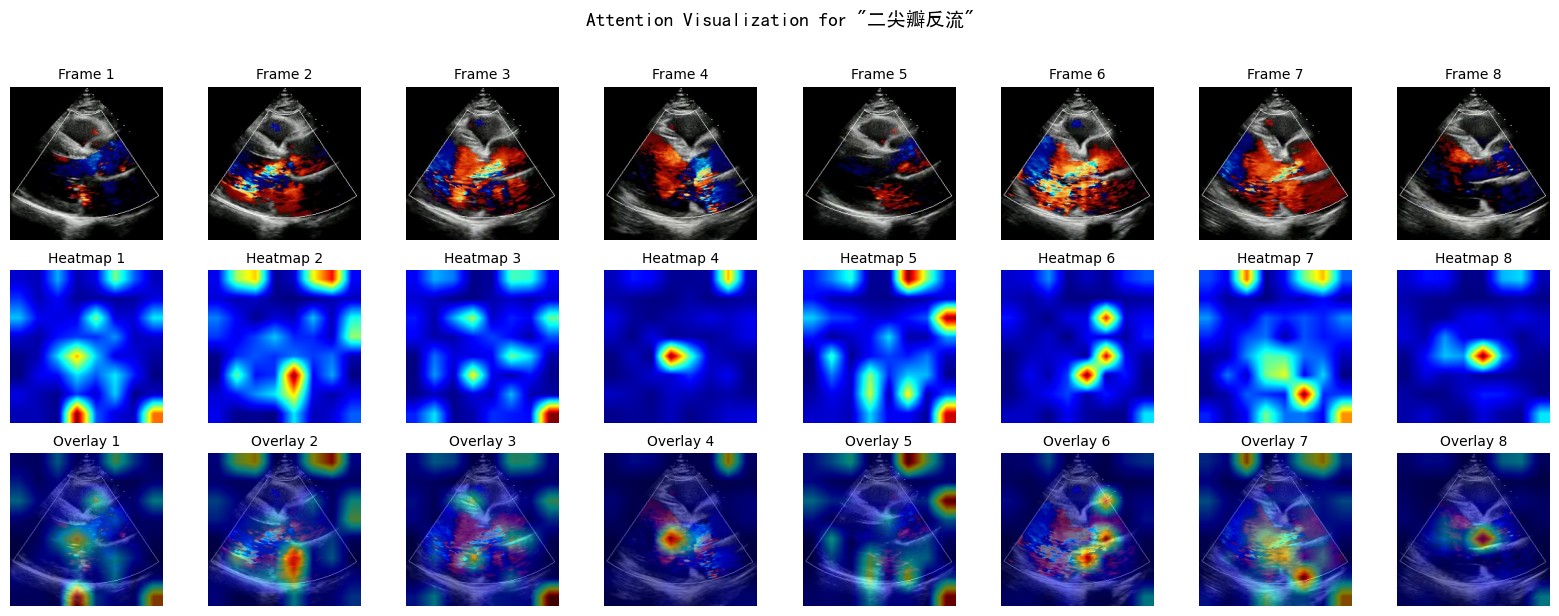

In [11]:
###  2.   有视频
msg= {
    "id": "Dataset/group_5/2024041804351700050569525e9",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_5/2024041804351700050569525e9/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_5/20240217033452000505695f0c0/Doppler_Parasternal_Long.mp4
在提供的图片中可以看到彩色多普勒显示了心脏内部血流的情况，在红色和蓝色分别代表血液流动的方向不同（红色表示向心方向，即从肺静脉流向左房；蓝色则相反）。如果存在二尖瓣反流，则会看到部分或全部颜色反转的现象。

然而仅凭一张静态图像很难准确判断是否存在二尖瓣反流以及其严重程度。通常需要结合多个切面、动态变化等信息进行综合分析才能做出诊断结论。
建议您咨询专业医生以获得更详细的解释与治疗方案。

输出token序列:
0 在 1 提供的 2 图片 3 中 4 可以看到 5 彩色 6 多 7 普 8 勒 9 显示 10 了 11 心脏 12 内部 13 血 14 流 15 的情况 16 ，在 17 红色 18 和 19 蓝色 20 分别 21 代表 22 血液 23 流动 24 的方向 25 不同 26 （ 27 红色 28 表示 29 向 30 心 31 方向 32 ， 33 即 34 从 35 肺 36 静脉 37 流向 38 左 39 房 40 ； 41 蓝色 42 则 43 相反 44 ）。 45 如果 46 存在 47 二 48 尖 49 瓣 50 反 51 流 52 ，则 53 会 54 看到 55 部分 56 或 57 全部 58 颜色 59 反转 60 的现象 61 。

 62 然而 63 仅 64 凭 65 一张 66 静态 67 图像 68 很难 69 准确 70 判断 71 是否存在 72 二 73 尖 74 瓣 75 反 76 流 77 以及 78 其 79 严重 80 程度 81 。 82 通常 83 需要 84 结合 85 多个 86 切 87 面 88 、 89 动态 90 变化 91 等 92 信息 93 进行 94 综合 95 分析 96 才能 97 做出 98 诊断 99 结论 100 。
 101 建议 102 您 103 咨询 104 专业 105 医生 106 以 107 获得 108 更 109 详细的 110 解释 111 与 112 治疗 113 方案 114 。 115 <|im_end|> 

注意力

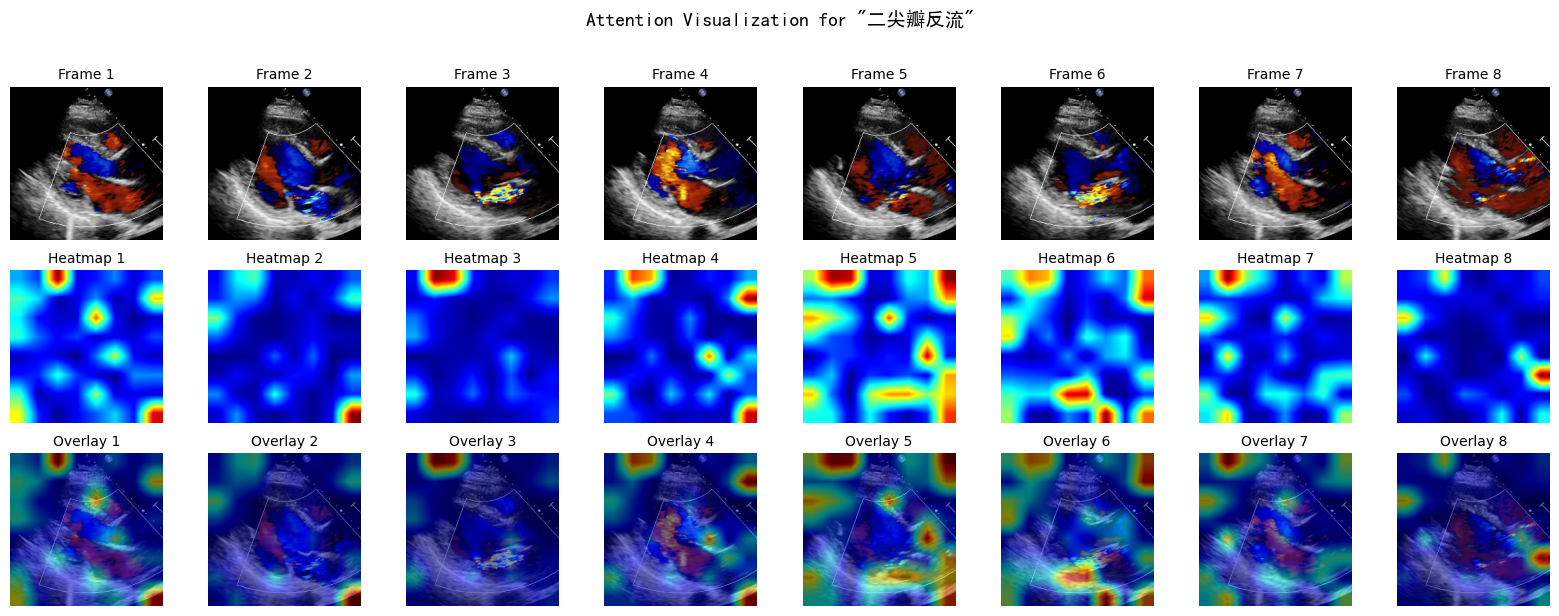

In [12]:
###  2.   有视频
msg={
    "id": "Dataset/group_5/20240217033452000505695f0c0",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_5/20240217033452000505695f0c0/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_5/2024040121443100050569525e9/Doppler_Parasternal_Long.mp4
在提供的图片中可以看到心脏内部结构的一部分，在显示了彩色多普勒信号（红色和蓝色），这通常用于检测血液流动的方向。然而，由于图像仅提供了一个二维切面视图且没有动画或连续帧序列来完整展示整个心动周期中的血流情况，因此无法准确判断是否存在二尖瓣反流及其严重程度。

要正确评估二尖瓣功能及是否存在反流以及其严重性度需要通过一系列详细的检查步骤包括但不限于：
1) 进行完整的四腔心房室成像以全面了解心脏的整体形态与大小。
2）进行详细的心脏彩超扫查以便于识别任何异常活动模式如逆向性的血流方向等现象；
3）必要时可结合其他影像学技术例如CTa或者mri进一步确认诊断结果并制定治疗方案；

建议您咨询专业心血管医生获取更精确的信息指导！

输出token序列:
0 在 1 提供的 2 图片 3 中 4 可以看到 5 心脏 6 内部 7 结构 8 的一部分 9 ，在 10 显示 11 了 12 彩色 13 多 14 普 15 勒 16 信号 17 （ 18 红色 19 和 20 蓝色 21 ）， 22 这 23 通常 24 用于 25 检测 26 血液 27 流动 28 的方向 29 。 30 然而 31 ， 32 由于 33 图像 34 仅 35 提供 36 了一个 37 二维 38 切 39 面 40 视 41 图 42 且 43 没有 44 动画 45 或 46 连续 47 帧 48 序列 49 来 50 完整 51 展示 52 整个 53 心动 54 周期 55 中的 56 血 57 流 58 情况 59 ， 60 因此 61 无法 62 准确 63 判断 64 是否存在 65 二 66 尖 67 瓣 68 反 69 流 70 及其 71 严重 72 程度 73 。

 74 要 75 正确 76 评估 77 二 78 尖 79 瓣 80 功能 81 及 82 是否 83 存在 84 反 85 流 86 以及 87 其 88 严重 89 性 90 度 91 需要 92 通过 93 一系列 94 详细的 95 检查 96 步骤 97 包括 98 但不限于 

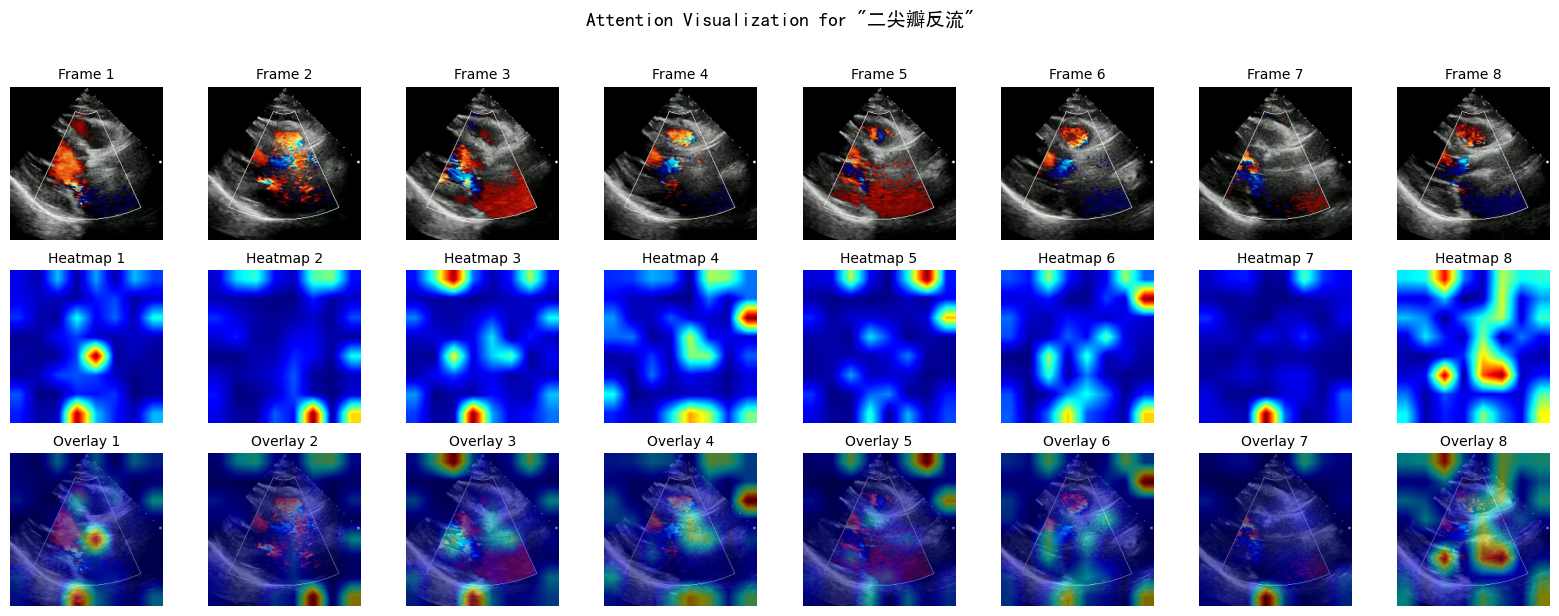

In [13]:
###  2.   有视频
msg=   {
    "id": "Dataset/group_5/2024040121443100050569525e9",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_5/2024040121443100050569525e9/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)